# Application of RF model
Application of the retrained RF model to the entire ParlaMint-SI corpus, producing a TSV table/dataset with IDs + RF annotations (```Datasets/ParlaMint-SI/utt_labels_RF.tsv```).

In [1]:
import pandas as pd
import joblib

## ParlaMint-SI preparation

In [2]:
df = pd.read_csv('../Datasets/ParlaMint-SI_dataset.csv', encoding='utf-8')
print(len(df))
df.head()

3876183


,utt_id,sent_id,text,annotations
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,4.052144
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Začenjam z nadaljevanjem 99. izredne seje Drža...,3.223034
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Obveščen sem, da se današnje seje ne morejo ud...",1.778516
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Vse prisotne lepo pozdravljam!,4.814360
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Prehajamo na 10.,3.219104


In [3]:
df1 = set(df['utt_id'])
count_df = len(df1)
print(f"Number of unique ID in df: {count_df}")


Number of unique ID in df: 311347


In [4]:
df = df.rename(columns={'utt_id':'ID', 'annotations': 'annotation_sent', 'text':'text_sent'})

In [5]:
aggregation = df.groupby('ID')['annotation_sent'].agg(
    mean = 'mean',
    median = 'median'
)
df = df.merge(aggregation, on='ID')

In [6]:
def count_avg(
    df: pd.DataFrame, id_col: str, sent_col: str, annotation_col: str) -> pd.DataFrame:
    df["count"] = df.groupby(id_col)[sent_col].transform("count")
    count_avg = (
        df.groupby(id_col)
        .apply(lambda x: (x[annotation_col] * x["count"]).sum() / x["count"].sum(), include_groups=False)
        .reset_index(name="count_avg")
    )

    df = df.merge(count_avg, on=id_col, how="left")
    return df


def char_avg(df: pd.DataFrame, id_col: str, sent_col: str, annotation_col: str) -> pd.DataFrame:
    df["char_length"] = df["text_sent"].apply(len)
    char_avg = (
        df.groupby(id_col)
        .apply(lambda x: (x[annotation_col] * x["char_length"]).sum() / x["char_length"].sum(), include_groups=False)
        .reset_index(name='char_avg')
    )
    df = df.merge(char_avg, on=id_col, how='left')
    return df

df = count_avg(df, id_col='ID', sent_col='sent_id', annotation_col='annotation_sent')
df = char_avg(df, id_col='ID', sent_col='sent_id', annotation_col='annotation_sent')
df.head()

,ID,sent_id,text_sent,annotation_sent,mean,median,count,count_avg,char_length,char_avg
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,4.052144,3.236904,3.219104,9,3.236904,67,2.497539
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Začenjam z nadaljevanjem 99. izredne seje Drža...,3.223034,3.236904,3.219104,9,3.236904,58,2.497539
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Obveščen sem, da se današnje seje ne morejo ud...",1.778516,3.236904,3.219104,9,3.236904,494,2.497539
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Vse prisotne lepo pozdravljam!,4.814360,3.236904,3.219104,9,3.236904,30,2.497539
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Prehajamo na 10.,3.219104,3.236904,3.219104,9,3.236904,16,2.497539


In [7]:
columns = ['ID', 'annotation_sent', 'count', 'char_length', 'mean', 'median', 'char_avg']
df = df[columns]

df.loc[:, 'sum'] = df.groupby('ID')['char_length'].transform('sum')
df.loc[:, 'Q1'] = df.groupby('ID')['annotation_sent'].transform(lambda x: x.quantile(0.25))
df.loc[:, 'Q3'] = df.groupby('ID')['annotation_sent'].transform(lambda x: x.quantile(0.75))
df = df.drop(columns=['char_length'])
df.head()

,ID,annotation_sent,count,mean,median,char_avg,sum,Q1,Q3
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,4.052144,9,3.236904,3.219104,2.497539,1005,2.961951,3.42729
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,3.223034,9,3.236904,3.219104,2.497539,1005,2.961951,3.42729
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,1.778516,9,3.236904,3.219104,2.497539,1005,2.961951,3.42729
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,4.814360,9,3.236904,3.219104,2.497539,1005,2.961951,3.42729
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,3.219104,9,3.236904,3.219104,2.497539,1005,2.961951,3.42729


In [8]:
data = df.drop_duplicates(subset=['ID']).reset_index(drop=True)
print(len(data))
data.head()

311347


,ID,annotation_sent,count,mean,median,char_avg,sum,Q1,Q3
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,4.052144,9,3.236904,3.219104,2.497539,1005,2.961951,3.427290
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,3.846659,27,2.805053,3.209449,2.851082,3653,2.232346,3.615555
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,4.758979,3,3.741684,3.427290,3.269488,127,3.233037,4.093134
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,4.019485,6,3.803255,4.052038,3.191090,456,3.940679,4.159993
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,4.758979,4,3.532954,3.213027,3.173941,149,2.985769,3.760212


## Applying retrained RF model to annotate the ParlaMint-SI corpus

In [9]:
rf = joblib.load('../Models/RF_retrained.pkl')

In [10]:
X = data[['count', 'sum', 'mean', 'median', 'char_avg', 'Q1', 'Q3']]

predictions = rf.predict(X)
data['predictions'] = predictions
data.head()


,ID,annotation_sent,count,mean,median,char_avg,sum,Q1,Q3,predictions
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,4.052144,9,3.236904,3.219104,2.497539,1005,2.961951,3.427290,2.42
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,3.846659,27,2.805053,3.209449,2.851082,3653,2.232346,3.615555,3.88
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,4.758979,3,3.741684,3.427290,3.269488,127,3.233037,4.093134,3.00
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,4.019485,6,3.803255,4.052038,3.191090,456,3.940679,4.159993,3.19
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,4.758979,4,3.532954,3.213027,3.173941,149,2.985769,3.760212,3.00


## Producing annotated ParlaMint-SI and analysis

In [11]:
corpus_columns = ['ID', 'predictions']
corpus = data[corpus_columns]
corpus = corpus.rename(columns={'predictions':'annotations'})
corpus

,ID,annotations
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,2.42
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,3.88
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,3.00
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,3.19
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,3.00
...,...,...
311342,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u242,2.99
311343,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u243,2.75
311344,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u244,3.02
311345,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u245,1.01


In [12]:
corpus.to_csv('../Datasets/ParlaMint-SI/utt_labels_RF.tsv', sep='\t', encoding='utf-8', index=False)

## Labeling and Analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
corpus = pd.read_csv('../Datasets/ParlaMint-SI/utt_labels_RF.tsv', sep='\t', encoding='utf-8')

In [2]:
import numpy as np
label_mapping = {
    0: 'Negative',
    1: 'Mixed Negative',
    2: 'Neutral Negative',
    3: 'Neutral Positive',
    4: 'Mixed Positive',
    5: 'Positive'
}

annotations = np.clip(np.round(corpus['annotations']), 0, 5).astype(int)
corpus['annotations_clip'] = annotations
corpus['labels'] = corpus['annotations_clip'].map(label_mapping)
#corpus = corpus.drop(columns=['annotations_clip'])
corpus.head()


,ID,annotations,annotations_clip,labels
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,2.42,2,Neutral Negative
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,3.88,4,Mixed Positive
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,3.00,3,Neutral Positive
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,3.19,3,Neutral Positive
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,3.00,3,Neutral Positive


In [3]:
#Mapping to 3-level scale
mapping = {
    0: 'Negative',
    1: 'Neutral',   
    2: 'Positive',
}

#corpus['sentiment'] = corpus['labels'].map(mapping)

sentiment = np.floor_divide(corpus['annotations_clip'], 2)
corpus['sentiment_no'] = sentiment
corpus['sentiment'] = corpus['sentiment_no'].map(mapping)
corpus.head(15)

,ID,annotations,annotations_clip,labels,sentiment_no,sentiment
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,2.42,2,Neutral Negative,1,Neutral
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,3.88,4,Mixed Positive,2,Positive
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,3.00,3,Neutral Positive,1,Neutral
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,3.19,3,Neutral Positive,1,Neutral
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,3.00,3,Neutral Positive,1,Neutral
5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u6,4.38,4,Mixed Positive,2,Positive
6,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u7,3.00,3,Neutral Positive,1,Neutral
7,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u8,3.94,4,Mixed Positive,2,Positive
8,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u9,3.07,3,Neutral Positive,1,Neutral
9,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u10,4.92,5,Positive,2,Positive


In [4]:
corpus = corpus.drop(columns=['annotations_clip', 'sentiment_no'])
corpus.head()

,ID,annotations,labels,sentiment
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,2.42,Neutral Negative,Neutral
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,3.88,Mixed Positive,Positive
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,3.00,Neutral Positive,Neutral
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,3.19,Neutral Positive,Neutral
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,3.00,Neutral Positive,Neutral


In [7]:
corpus.to_csv('../Datasets/ParlaMint-SI/utt_labels_RF.tsv', sep='\t', encoding='utf-8', index=False)

In [8]:
count_labels = corpus.value_counts('labels')
labels_percentage = (count_labels / count_labels.sum()) * 100
count_sentiment = corpus.value_counts('sentiment')
sentiment_percentage = (count_sentiment / count_sentiment.sum()) * 100

print(count_labels)
print(labels_percentage)
print(count_sentiment)
print(sentiment_percentage)

labels
Neutral Positive    155668
Negative             66231
Neutral Negative     36444
Mixed Negative       32109
Mixed Positive       15934
Positive              4961
Name: count, dtype: int64
labels
Neutral Positive    49.998233
Negative            21.272407
Neutral Negative    11.705268
Mixed Negative      10.312931
Mixed Positive       5.117762
Positive             1.593399
Name: count, dtype: float64
sentiment
Neutral     192112
Negative     98340
Positive     20895
Name: count, dtype: int64
sentiment
Neutral     61.703501
Negative    31.585337
Positive     6.711162
Name: count, dtype: float64


## Analysis - Labels distribution

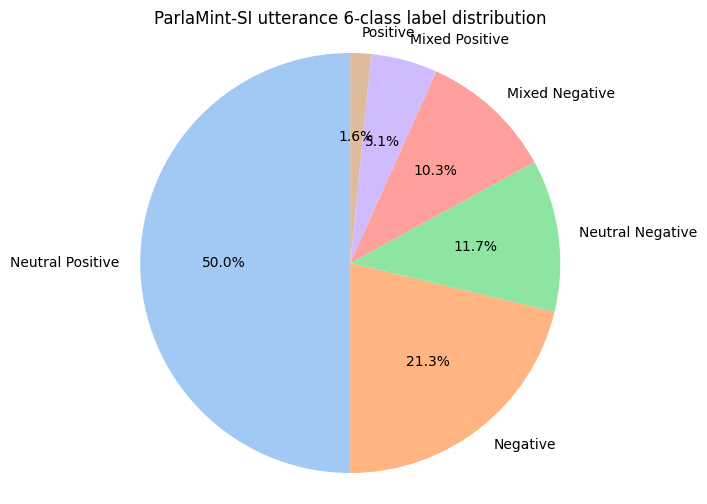

In [9]:
# Pie chart - 6-class labels
import matplotlib.pyplot as plt
import seaborn as sns

palette = sns.color_palette('pastel')

plt.figure(figsize=(8, 6))
plt.pie(labels_percentage, labels=labels_percentage.index, autopct='%1.1f%%', startangle=90, colors=palette)
plt.title('ParlaMint-SI utterance 6-class label distribution')
plt.axis('equal')
plt.savefig('../Figures/ParlaMint-SI_RF_utt_6class.png', dpi=300)
plt.show()

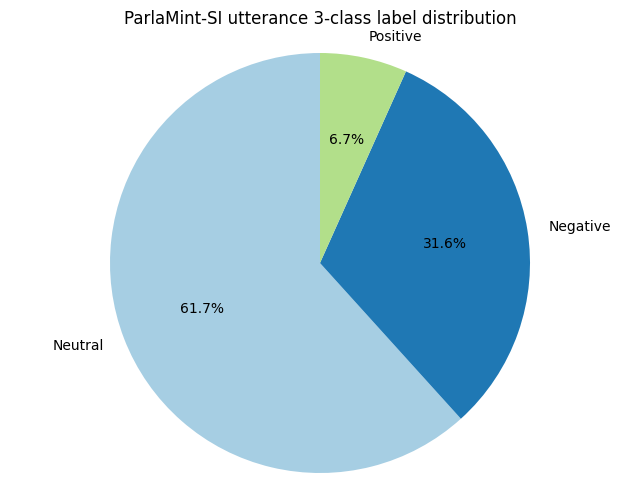

In [10]:
# Pie chart - 3-class labels
import matplotlib.pyplot as plt
import seaborn as sns

palette2 = sns.color_palette('Paired')

plt.figure(figsize=(8, 6))
plt.pie(sentiment_percentage, labels=sentiment_percentage.index, autopct='%1.1f%%', startangle=90, colors=palette2)
plt.title('ParlaMint-SI utterance 3-class label distribution')
plt.axis('equal')
plt.savefig('../Figures/ParlaMint-SI_RF_utt_3class.png', dpi=300)
plt.show()